In [1]:
import numpy as np
import pandas as pd

In [2]:
df=pd.read_csv("/content/student_dataset_10000_rows.csv")

In [44]:
df.head()

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
0,7,56,8,7,10,62,100.00,Placed
1,4,69,5,3,8,56,100.00,Placed
2,11,60,7,6,10,45,100.00,Placed
3,8,99,9,8,4,55,90.17,Placed
4,5,52,8,6,8,40,78.82,Placed


In [5]:
df.isnull().mean()*100

,0
study_hours,0.0
attendance,0.0
sleep_hours,0.0
internet_usage,0.0
assignments_completed,0.0
previous_score,0.0
exam_score,0.0
placement_status,0.0


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
from sklearn.model_selection import cross_val_score


In [9]:
df.shape

(10000, 8)

In [10]:
X=df.iloc[:,0:7]
y=df.iloc[:,-1]

In [46]:
lc=LabelEncoder()
y=lc.fit_transform(y)
y


array([1, 1, 1, ..., 1, 1, 1])

In [45]:
df.head()

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
0,7,56,8,7,10,62,100.00,Placed
1,4,69,5,3,8,56,100.00,Placed
2,11,60,7,6,10,45,100.00,Placed
3,8,99,9,8,4,55,90.17,Placed
4,5,52,8,6,8,40,78.82,Placed


In [23]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [24]:
dt=DecisionTreeClassifier(max_depth=5)
dt.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=5)

In [25]:
y_predict=dt.predict(X_test)

In [28]:
accuracy=accuracy_score(y_test,y_predict)

In [29]:
accuracy

1.0

In [34]:
score=cross_val_score(dt,X,y,cv=5,scoring="accuracy").mean()

In [33]:
score

np.float64(1.0)

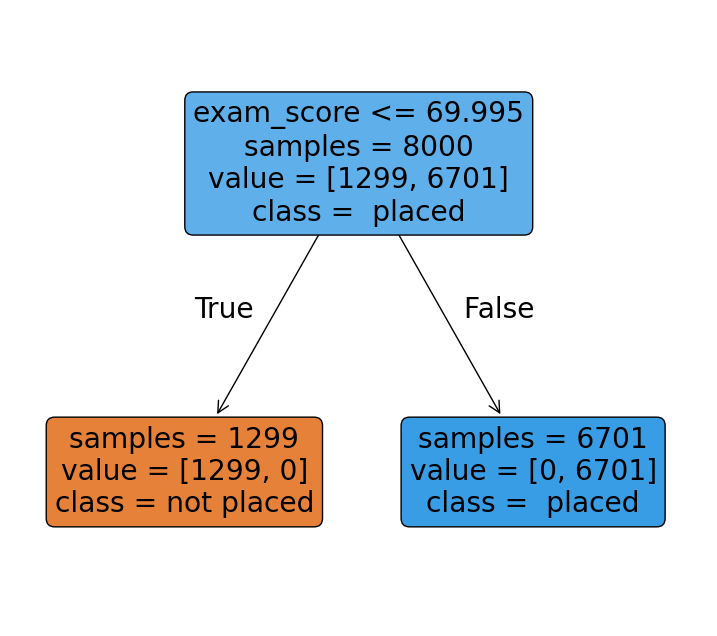

In [49]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(9, 8))

plot_tree(
    dt,
    filled=True,
    feature_names=X.columns,
    class_names=["not placed", " placed"],
     rounded=True,
    max_depth=5,
    impurity=False
)

plt.show()